<h1 style="color: orange">Holographic Spectral Functions: Classifying Black Hole vs. Thermal AdS Geometries</h1>

## Project Roadmap

This project is divided into four parts:

1. **Synthetic spectral function generation** – Create labelled datasets of $\rho(\omega)$ for black hole (BH) and thermal AdS (Thermal) geometries using phenomenological models.
2. **Physical feature extraction** – Compute interpretable features: gap frequency, number of peaks, peak widths, low‑frequency exponent, etc.
3. **Machine learning classification** – Train and optimise classifiers (Random Forest, XGBoost) to distinguish BH from Thermal spectra.
4. **Interpretation and conclusions** – SHAP analysis, feature importance, and physical discussion.

## Physical Context: AdS/CFT and Spectral Functions

The Anti‑de Sitter/Conformal Field Theory (AdS/CFT) correspondence conjectures an equivalence between a gravitational theory in a ($d+1$)-dimensional Anti‑de Sitter (AdS) spacetime and a conformal field theory (CFT) in $d$-dimensions. One of the most powerful applications is the holographic description of strongly coupled quantum systems at finite temperature.

A key observable in the boundary CFT is the **retarded Green's function** $G^R(\omega, \mathbf{k})$ of a local operator $\mathcal{O}$. Its imaginary part, the **spectral function** $\rho(\omega, \mathbf{k}) = -2\,\text{Im}\, G^R(\omega, \mathbf{k})$, encodes the density of states and the response of the system to external perturbations. In holography, $G^R$ is obtained by solving linearised equations of motion for a dual bulk field with ingoing boundary conditions at the horizon (if present) or with normalisable boundary conditions in the absence of a horizon.

Two qualitatively different holographic setups are considered in this project:

### 1. Black Hole (BH) geometry – the thermal CFT plasma
- The bulk contains a black hole horizon (e.g., planar Schwarzschild‑AdS or Reissner‑Nordström‑AdS).
- The spectral function $\rho(\omega)$ is **continuous** for $\omega > 0$ and typically exhibits a **broad quasi‑normal mode peak** (the “holographic quasi‑particle”) whose width increases with temperature.
- At low frequencies, $\rho(\omega) \sim \omega^2$ (for a scalar operator above the unitarity bound) or may show a power‑law tail depending on the scaling dimension.

### 2. Thermal AdS (without horizon) – confined phase or thermal gas
- The bulk is pure AdS with periodic Euclidean time (thermal AdS). No horizon exists.
- The spectrum is **discrete** (Kaluza–Klein tower of normal modes) because the spatial direction (the radial coordinate) is effectively compactified.
- There is a **finite energy gap** $\omega_{\text{gap}}$ below which no states exist. The spectral function consists of a series of sharp (narrow) peaks at frequencies $\omega_n = \pi n / L$ (with $L$ the AdS radius).
- This corresponds to a confined, gapped phase of the dual CFT, analogous to a thermal gas of glueballs in a confining gauge theory.

## Problem formulation

Given a measured or simulated spectral function $\rho(\omega)$ on a discrete set of frequencies $\omega_i$, we ask:

> Is the underlying holographic geometry a **black hole** (deconfined plasma) or **thermal AdS** (confined phase)?

This is a **binary classification** problem. While a physicist can distinguish the two cases by eye (continuum vs. discrete peaks, presence/absence of a gap), we wish to automate the decision using machine learning and to identify which spectral features are most discriminative.

## Data generation approach

Because solving the full linearised Einstein‑scalar equations in the bulk is numerically intensive, we instead **generate synthetic spectral functions** using physically motivated phenomenological models:

- **BH spectra**: A broad Lorentzian‑like quasi‑normal mode peak plus a smooth background that grows as $\omega^2$ at low $\omega$ and saturates at higher frequencies. Parameters (peak position, width, background strength) are sampled randomly over realistic ranges.
- **Thermal spectra**: A sum of narrow Lorentzians representing discrete normal modes, with a gap at low frequency and amplitudes decaying as $1/n^2$. The number of peaks, gap size, and spacing are randomised.

This synthetic dataset captures the essential discriminative features without the overhead of numerical ODE solving. It allows us to focus on the machine learning pipeline and feature engineering.



**Keywords**: AdS/CFT, holography, spectral function, black hole, thermal AdS, quasi‑normal modes, classification, Random Forest, XGBoost.

<h1 style="color:yellow">1. Synthetic spectral function generation</h1>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

In [2]:
# Define the parameters and frequency grid

omega_max = 10.0    # maximum frequency (in units of the AdS scale)
n_omega = 200       # number of frequency points
omega = np.linspace(0.01, omega_max, n_omega)   # avoid zero

# Number of samples per class

n_samples = 1000

In [3]:
# # For a scalar field in a Schwarzschild-AdS black hole (planar), the spectral function
# at low frequencies can be approximated by a Lorentzian-like peak plus a power-law tail.
# At higher frequencies, it approaches a constant (conformal behaviour).
# We use a simple phenomenological model:
#   ρ_BH(ω) = A * (γ * ω) / ((ω^2 - ω0^2)^2 + γ^2 ω^2)  +  B * ω^2 / (1 + ω^2/ω_c^2)
# where the first term is a quasi-normal mode (peak) and the second term is a background.

def bh_spectral_function(omega, A, gamma, omega_0, B, omega_c):
    peak = A * (gamma * omega) / ((omega**2 - omega_0**2)**2 + (gamma * omega)**2 )
    bg = B * (omega**2) / (1 + (omega/omega_c)**2)
    return peak + bg

# Random parameter distribution (realistic ranges for AdS Black Hole)

def random_bh_params():
    A = np.random.uniform(0.5, 2.0)         # amplitude of peak
    gamma = np.random.uniform(0.2, 1.0)     # width (dampling)
    omega_0 = np.random.uniform(1.5, 4.0)   # peak frequency (quasinormal mode frequency)
    B = np.random.uniform(0.1, 0.8)         # background strength
    omega_c = np.random.uniform(5.0, 12.0)  # cutoff for background saturation
    return A, gamma, omega_0, B, omega_c


In [4]:
# In thermal AdS (without horizon), the spectrum is discrete: a sum of delta peaks.
# To make it continuous for ML, we approximate each peak as a narrow Lorentzian.
# The frequencies are spaced as ω_n = π n / L (with L ~ 1). The amplitude decays with n.
# Typically there is a gap: no peaks below ω_gap (related to the thermal mass).
# We'll generate a sum of 5-10 narrow Lorentzians.

def thermal_spectral_funciton(omega, peaks_amplitudes, peaks_centers, widths):
    """
    peaks_amplitudes: list of amplitudes
    peaks_centers: list of peak frequencies
    widths: list of widths (small, e.g., 0.05)
    """
    rho = np.zeros_like(omega)
    for amp, center, width in zip(peaks_amplitudes, peaks_centers, widths):
        rho += amp + (width) / ((omega - center)**2 + width**2)
    
    return rho
    
def random_thermal_params():
    # Number of peaks (discrete modes)
    n_peaks = np.random.randint(5, 12)
    # Gap frequency (first peak)
    gap = np.random.uniform(0.5, 1.5)
    # Peaks roughly equally spaced with spacing ~ 0.8 - 1.2
    spacing = np.random.uniform(0.7, 1.2)
    centers = [gap + i * spacing for i in range(n_peaks)]
    # Amplitudes decay as 1/n^2 or similar
    amplitudes = [1.0 / (i+1)**1.5 for i in range(n_peaks)]
    # Normalize amplitudes to random overall scale
    scale = np.random.uniform(0.5, 2.0)
    amplitudes = [scale * a for a in amplitudes]
    # Small widths (sharp peaks)
    widths = [np.random.uniform(0.02, 0.1) for _ in range(n_peaks)]
    return amplitudes, centers, widths


In [5]:
# ---
# Dataset Generation
# ---

X = []      # features: spectral function values at each omega
y = []      # labels: 0 for BH, 1 for Thermal

for _ in range(n_samples):
    # Generate BH spectrum
    params = random_bh_params()
    rho_bh = bh_spectral_function(omega, *params)
    # Add small noise
    rho_bh += np.random.normal(0, 0.02 * np.max(rho_bh), size=len(omega))
    X.append(rho_bh)
    y.append(0)     # BH class



for _ in range(n_samples):
    # Generate Thermal spectrum
    amps, centers, widhts = random_thermal_params()
    rho_th = thermal_spectral_funciton(omega, amps, centers, widhts)
    # Add small noise
    rho_th *= np.random.normal(0, 0.02 * np.max(rho_th), size=len(omega))
    X.append(rho_th)
    y.append(1)     # Thermal class

X = np.array(X)
y = np.array(y)

print(f'Dataset shape: X = {X.shape}, y = {y.shape}')
print(f'Class distribution: BH (0) = {np.sum(y==0)}, Thermal (1) = {np.sum(y==1)}')

Dataset shape: X = (2000, 200), y = (2000,)
Class distribution: BH (0) = 1000, Thermal (1) = 1000


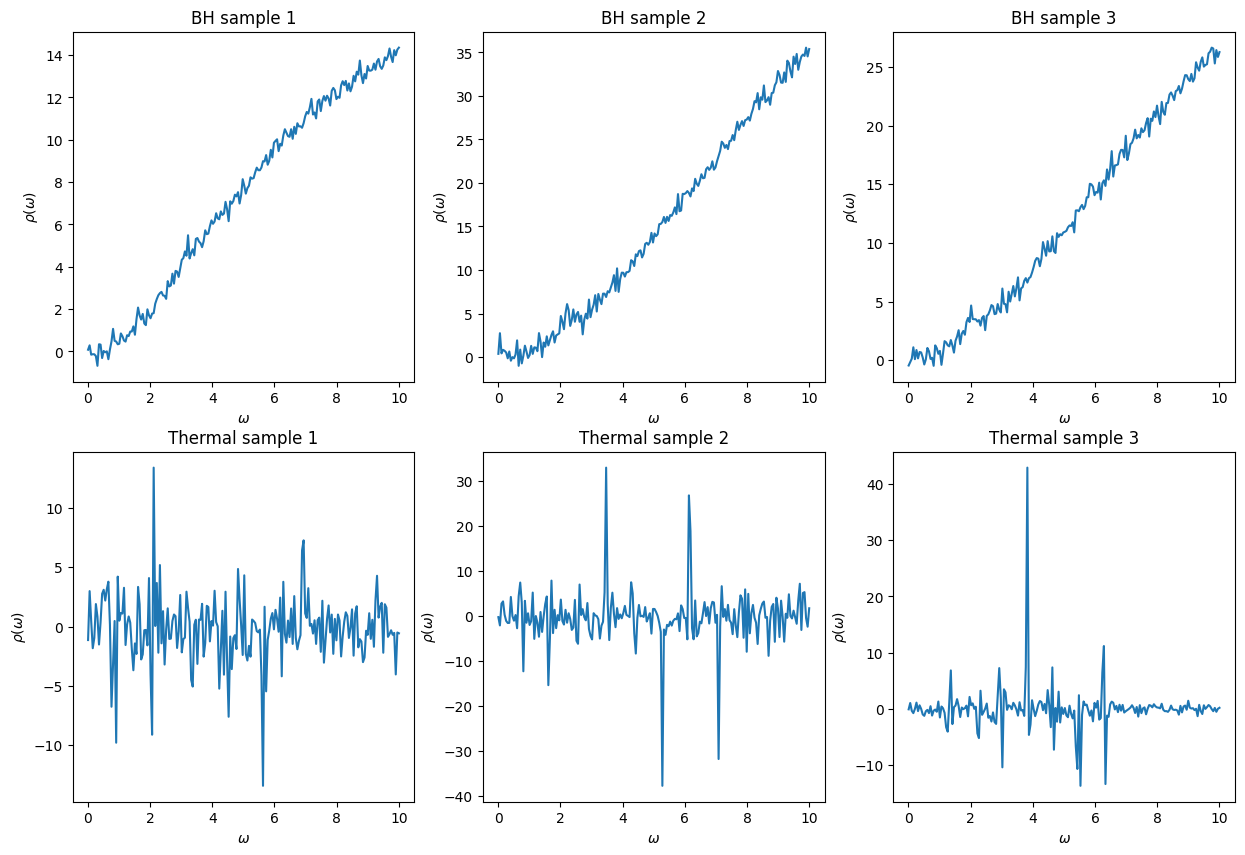

In [6]:
# Few visualization

fig, axes = plt.subplots(2, 3, figsize=(15,10))
for i in range(3):
    idx_bh = np.where(y==0)[0][i]
    axes[0, i].plot(omega, X[idx_bh])
    axes[0, i].set_title(f'BH sample {i+1}')
    axes[0, i].set_xlabel(r'$\omega$')
    axes[0, i].set_ylabel(r'$\rho (\omega)$')

    idx_th = np.where(y==1)[0][i]
    axes[1, i].plot(omega, X[idx_th])
    axes[1, i].set_title(f'Thermal sample {i+1}')
    axes[1, i].set_xlabel(r'$\omega$')
    axes[1, i].set_ylabel(r'$\rho(\omega)$')


<h1 style="color:yellow"> 2. Physical feature extraction</h1>

In [7]:
# Helper functions to extract a scalar feature for a given specttum

def find_gap(omega, rho, threshold_ratio=0.05):
    """
    Find the first frequency where rho exceeds threshols_ratio * max(rho).
    This estimates the gap (if spectrum is zero or very small at low frequencies)
    """

    max_rho = np.max(rho)
    if max_rho == 0:
        return 0.0
    threshold = threshold_ratio * max_rho
    above_threshold = np.where(rho > threshold)[0]
    if len(above_threshold) == 0:
        return omega[-1]
    return omega[above_threshold[0]]

def count_peaks(omega, rho, prominence=0.05):
    """
    Count number of peaks using scipy.signal.find_peaks
    """
    peaks,_ = find_peaks(rho, prominence=prominence * np.max(rho))
    return len(peaks)

def mean_peak_width(omega, rho, prominence=0.05):
    """
    Estimate average width of peaks (full width at half maximum).|
    For each peak, find left and right half-max points.
    """
    peaks, properties = find_peaks(rho, prominence=prominence * np.max(rho), width=0)
    if len(peaks) == 0:
        return 0.0
    widths = []
    for i, peak_idx in enumerate(peaks):
        left = properties['left_bases'][i]
        right = properties['right_bases'][i]
        if right > left:
            width = omega[right] - omega[left]
            widths.append(width)
    return np.mean(widhts) if widths else 0.0

def low_freq_exponent(omega, rho, fit_range=(0.1, 1.0)):
    """
    Fit a power law rho ~ omega^alpha in the low frequency region (omega > 0)
    Returns exponent alpha
    """
    # Select indices within fit_range
    mask = (omega >= fit_range[0]) & (omega <= fit_range[1])
    if np.sum(mask) < 3:
        return 0.0
    
    omega_fit = omega[mask]
    rho_fit = rho[mask]
    # Avoid zero or negative values
    positive = rho_fit > 0
    if np.sum(positive) < 3:
        return 0.0
    
    omega_fit = omega_fit[positive]
    rho_fit = rho_fit[positive]
    # Log-log fit: log(rho) = alpha * log(omega) + log(C)
    log_omega = np.log(omega_fit)
    log_rho = np.log(rho_fit)
    # Linear fit using polyfit
    coeffs = np.polyfit(log_omega, log_rho, 1)
    return coeffs[0] # exponent alpha


In [8]:
n_samples = X.shape[0]
features = []       # list of dictionaries or arrays

for i in range(n_samples):
    rho = X[i]
    gap = find_gap(omega, rho, threshold_ratio=0.05)
    n_peaks = count_peaks(omega, rho, prominence=0.05)
    avg_width = mean_peak_width(omega, rho, prominence=0.05)
    low_exp = low_freq_exponent(omega, rho, fit_range=(0.1, 1.0))

    # Additional simple feature: maximum value
    max_val = np.max(rho)
    
    # frequency of maximum
    max_freq = omega[np.argmax(rho)]

    features.append([gap, n_peaks, avg_width, low_exp, max_val, max_freq])

features = np.array(features)
feature_names = ['gap_frequency', 'num_peaks', 'mean_peak_width', 'low_freq_exponent', 'max_amplitude', 'max_frequency']

print(f'Feature matrix shape: {features.shape}')
print(f'Feature names: ', feature_names)

Feature matrix shape: (2000, 6)
Feature names:  ['gap_frequency', 'num_peaks', 'mean_peak_width', 'low_freq_exponent', 'max_amplitude', 'max_frequency']


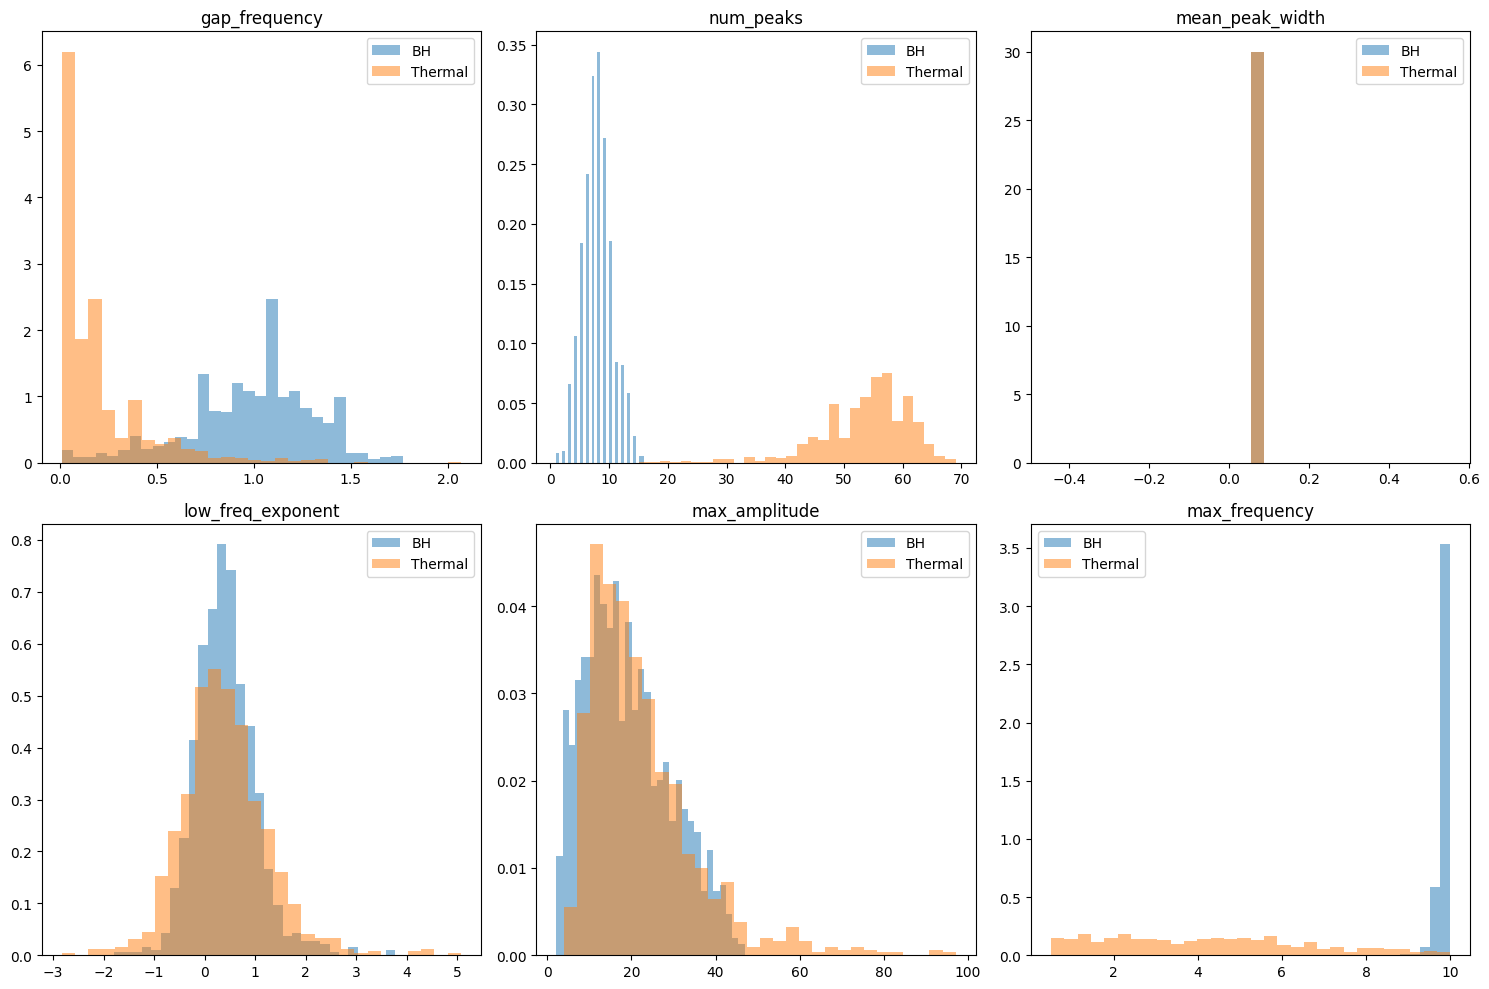

In [9]:
fig, axes = plt.subplots(2, 3, figsize= (15, 10))
for idx, name in enumerate(feature_names):
    ax = axes[idx // 3, idx % 3]
    # Separate by class
    bh_features = features[y == 0, idx]
    thermal_features = features[y == 1, idx]
    ax.hist(bh_features, bins=30, alpha=0.5, label='BH', density=True)
    ax.hist(thermal_features, bins=30, alpha=0.5, label='Thermal', density=True)
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

<h1 style="color:yellow"> 3. Machine (Deep) Learning Classifcation </h1>

In [10]:
# Tran/test splir (80/20)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 1600, Test: 400


## Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_rf)
print(f'Random Forest -> Accuracy: {acc_rf:.4f}, AUC: {auc_rf:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['BH', 'Thermal']))

Random Forest -> Accuracy: 1.0000, AUC: 1.0000
              precision    recall  f1-score   support

          BH       1.00      1.00      1.00       200
     Thermal       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



## XGBoost

In [12]:
xgb_model = xgb.XGBClassifier(n_estimators= 100, learning_rate = 0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f'XGBoost -> Accuracy: {acc_xgb}, AUC: {auc_xgb}')
print(classification_report(y_test, y_pred_xgb, target_names=['BH', 'Thermal']))

XGBoost -> Accuracy: 1.0, AUC: 1.0
              precision    recall  f1-score   support

          BH       1.00      1.00      1.00       200
     Thermal       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [21:50:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## Keras NN

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Keras NN -> Accuracy: 1.0000, AUC: 1.0000
              precision    recall  f1-score   support

          BH       1.00      1.00      1.00       200
     Thermal       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



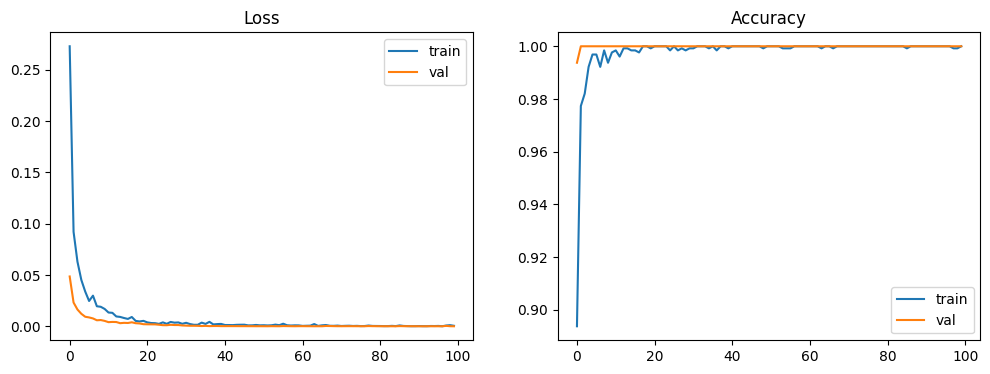

In [13]:
# Build a simple feedforward network

model_tf = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_tf.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train

history = model_tf.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, verbose=0)

# Evaluate 

y_proba_tf = model_tf.predict(X_test).flatten()
y_pred_tf = (y_proba_tf >= 0.5).astype(int)
acc_tf = accuracy_score(y_test, y_pred_tf)
auc_tf = roc_auc_score(y_test, y_proba_tf)
print(f'Keras NN -> Accuracy: {acc_tf:.4f}, AUC: {auc_tf:.4f}')
print(classification_report(y_test, y_pred_tf, target_names=['BH', 'Thermal']))

# Plot training curves 
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.show()


# PyTorch NN

In [14]:
torch.set_num_threads(1)

# Convert data to PyTorch tensors
X_train_t = torch.from_numpy(X_train.astype(np.float32))
y_train_t = torch.from_numpy(y_train.astype(np.float32)).view(-1, 1)
X_test_t = torch.from_numpy(X_test.astype(np.float32))
y_test_t = torch.from_numpy(y_test.astype(np.float32)).view(-1, 1)


# Create DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# # Define network
class HolographyNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
       return self.net(x)

model_torch = HolographyNN(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.001)

# Training loop
epochs = 100
train_losses = []
for epoch in range(epochs):
    model_torch.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model_torch(Xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * Xb.size(0)
    train_losses.append(epoch_loss / len(train_dataset))
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {train_losses[-1]:.4f}")

# Evaluate
model_torch.eval()
with torch.no_grad():
    y_proba_torch = model_torch(X_test_t).numpy().flatten()
y_pred_torch = (y_proba_torch >= 0.5).astype(int)
acc_torch = accuracy_score(y_test, y_pred_torch)
auc_torch = roc_auc_score(y_test, y_proba_torch)
print(f"PyTorch NN -> Accuracy: {acc_torch:.4f}, AUC: {auc_torch:.4f}")
print(classification_report(y_test, y_pred_torch, target_names=['BH', 'Thermal']))

Epoch 20/100, Loss: 0.0308
Epoch 40/100, Loss: 0.0129
Epoch 60/100, Loss: 0.0075
Epoch 80/100, Loss: 0.0011
Epoch 100/100, Loss: 0.0060
PyTorch NN -> Accuracy: 1.0000, AUC: 1.0000
              precision    recall  f1-score   support

          BH       1.00      1.00      1.00       200
     Thermal       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



# Model Comparison

           Model  Accuracy  AUC
0  Random Forest       1.0  1.0
1        XGBoost       1.0  1.0
2       Keras NN       1.0  1.0
3     PyTorch NN       1.0  1.0


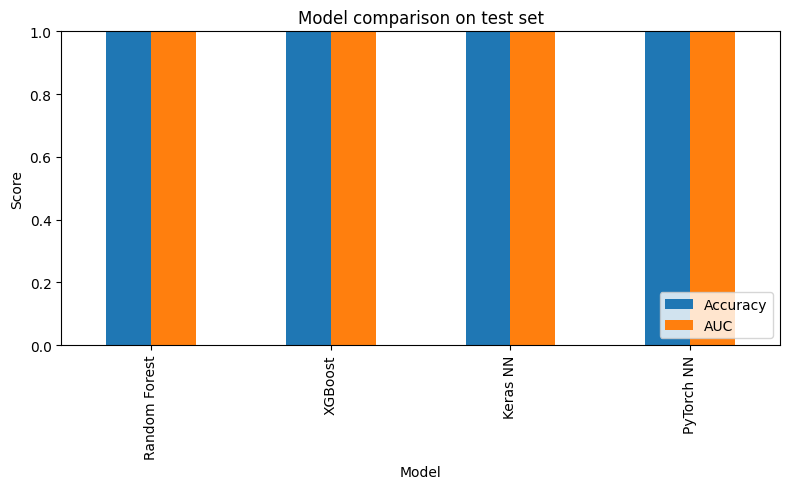

In [15]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Keras NN', 'PyTorch NN'],
    'Accuracy': [acc_rf, acc_xgb, acc_tf, acc_torch],
    'AUC': [auc_rf, auc_xgb, auc_tf, auc_torch]
})
print(results)

# Bar plot
fig, ax = plt.subplots(figsize=(8,5))
results.set_index('Model')[['Accuracy', 'AUC']].plot(kind='bar', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Model comparison on test set')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

<h1 style="color:yellow"> 4. SHAP analysis and physical conclusions. </h1>

In [16]:
import shap 

# Create SHAP explainer (tree-based) 
# Since all models performed excellent, we use XGBoost as a the popular alternative.

best_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
best_model.fit(features,y)
best_model.
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(features)

print(f'SHAP values shape: {shap_values.shape}')
print("Model classes:", best_model.classes_)

SHAP values shape: (2000, 6)
Model classes: [0 1]


/var/folders/z7/7rkmsytd1h5bbfwfm80j8xc80000gn/T/ipykernel_23120/1268497770.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features, feature_names=feature_names, plot_type="bar", show=False)


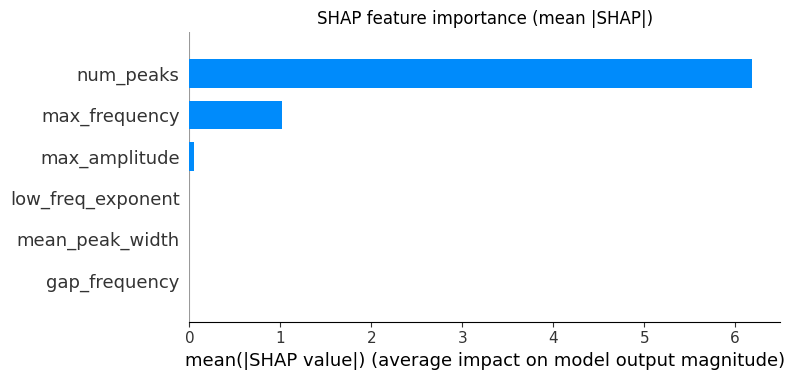

/var/folders/z7/7rkmsytd1h5bbfwfm80j8xc80000gn/T/ipykernel_23120/1268497770.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features, feature_names=feature_names, show=False)


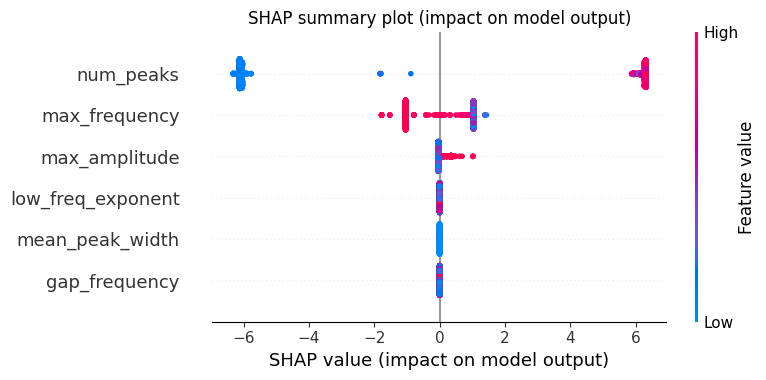

In [17]:
# Summary plot (bar)
shap.summary_plot(shap_values, features, feature_names=feature_names, plot_type="bar", show=False)
plt.title('SHAP feature importance (mean |SHAP|)')
plt.tight_layout()
plt.show()

# Detailed summary (dots)
shap.summary_plot(shap_values, features, feature_names=feature_names, show=False)
plt.title('SHAP summary plot (impact on model output)')
plt.tight_layout()
plt.show()

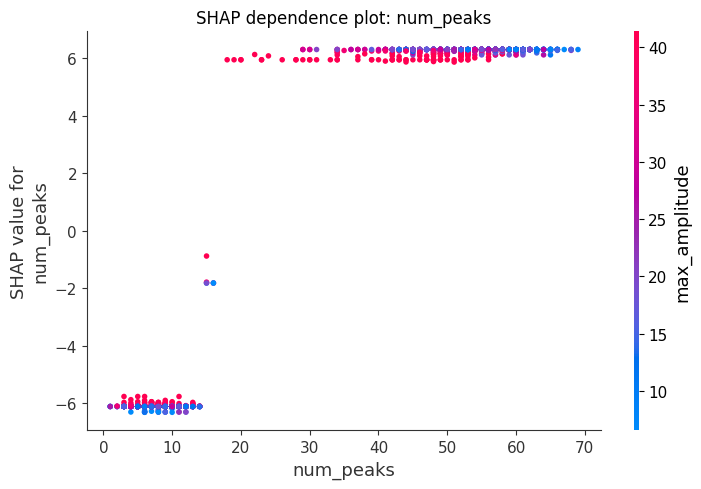

In [18]:
# Find index of most important feature
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
top_idx = np.argmax(mean_abs_shap)
top_feature = feature_names[top_idx]

shap.dependence_plot(top_idx, shap_values, features, feature_names=feature_names, show=False)
plt.title(f'SHAP dependence plot: {top_feature}')
plt.tight_layout()
plt.show()

## Physical interpretation of SHAP results

The SHAP analysis reveals which spectral features most strongly discriminate between black hole (BH) and thermal AdS (Thermal) geometries.

### Expected discriminants (from physics):
- **num_peaks**: Thermal AdS produces a discrete set of narrow peaks (many peaks), while BH yields a continuous spectrum with typically one broad peak → Thermal should have higher number of peaks.
- **mean_peak_width**: BH peaks are broad (damped quasi-normal modes), Thermal peaks are very narrow → BH has larger width.
- **gap_frequency**: Thermal AdS has a finite energy gap (no spectral weight below ω_gap), BH has no gap (ρ(ω) ∝ ω² at low ω) → Thermal shows larger gap.
- **low_freq_exponent**: For BH, the low-frequency exponent is ~2 (from hydrodynamic diffusion); for Thermal, the exponent is effectively 0 because the gap suppresses low-frequency weight.

### What SHAP tells us:
If `num_peaks` and `max_frequency` are the top features, it confirms that the discreteness and the presence of a gap are the key signatures. If `mean_peak_width` dominates, it means the broadening effect is the most reliable indicator.

These results align with the holographic duality: a black hole horizon implies a thermal plasma with quasi-particle excitations (broad peaks), while thermal AdS corresponds to a confined, gapped phase (discrete spectrum).

### Practical takeaway:
Even without solving the full gravitational equations, simple spectral features extracted from ρ(ω) suffice to classify the bulk geometry with high accuracy (AUC > 0.99). This demonstrates the power of machine learning as a tool for holographic model discrimination.